# 02 · HVG selection & PCA (malignant cells)

**Goal (Q2.2).** From 23,686 genes pick the ~2,000 most informative
(highly variable genes, HVG), then compress cells into a 50-D PCA space that
all downstream steps (Harmony, UMAP, Leiden) will use.

**Pipeline order (the order matters):**
`load → subset to malignant → HVG → PCA`

**What this notebook produces**

| Output | Path |
|---|---|
| Malignant AnnData + HVG marks + PCA | `data/processed/tirosh_malignant_pca.h5ad` |
| 4 diagnostic figures | `results/figures/02_*.png` |

### Design decisions (recorded *before* code, per project convention)

1. **Subset to malignant cells first** (≈1,257). Balderson et al. 2024
   re-analyzed Tirosh by subsetting to the ~1,252 malignant cells; we do the
   same so our results are directly comparable. HVGs computed *after*
   subsetting therefore capture **within-tumor state heterogeneity**
   (melanocytic ↔ transitory ↔ neural-crest ↔ undifferentiated), not
   immune-vs-tumor differences.
2. **`flavor="seurat"`, not `"seurat_v3"`.** `seurat_v3` requires *raw
   integer counts*; our matrix is `log2(TPM/10+1)`. The `seurat` flavor is
   the one designed for already-logarithmized data.
3. **No `normalize_total`, no `log1p`, no `scale`.** The data is already
   normalized + log-transformed. `sc.pp.scale` (z-scoring each gene) is a
   standard step on log-*count* data but **introduces artifacts on log-TPM**
   (TPM is already a per-cell normalization; scaling on top distorts
   between-gene relationships). `sc.pp.pca` mean-centers internally
   (`zero_center=True`), which is all the centering PCA needs.
4. **`n_comps=50`.** Standard; downstream Harmony/Leiden use ~30–40 PCs, so
   50 leaves headroom.
5. **Mark HVGs, don't delete genes.** PCA is computed on the HVG subset via
   `mask_var="highly_variable"`, but all 23,686 genes are kept in `.var` so
   canonical markers (MITF/SOX10/NGFR/AXL) remain available for Tsoi-state
   scoring in a later quest.

## Step 0 — Imports & paths

In [1]:
import scanpy as sc
import anndata as ad
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import date
from importlib.metadata import version

%matplotlib inline
sc.settings.verbosity = 1

def _resolve(*candidates):
    for c in candidates:
        p = Path(c)
        if p.exists() or p.parent.exists():
            return p
    return Path(candidates[0])

PROC   = _resolve("../data/processed", "data/processed")
FIGDIR = _resolve("../results/figures", "results/figures")
FIGDIR.mkdir(parents=True, exist_ok=True)
sc.settings.figdir = FIGDIR

IN_H5AD  = PROC / "tirosh_anndata_raw.h5ad"
OUT_H5AD = PROC / "tirosh_malignant_pca.h5ad"
assert IN_H5AD.exists(), f"Run notebook 01 first; missing {IN_H5AD}"

print("scanpy", version("scanpy"), "| anndata", version("anndata"),
      "| numpy", version("numpy"))
print("in :", IN_H5AD.resolve())
print("out:", OUT_H5AD.resolve())

scanpy 1.11.5 | anndata 0.12.14 | numpy 2.4.5
in : /Users/youyouwu/Desktop/melanoma-scrnaseq-reanalysis/data/processed/tirosh_anndata_raw.h5ad
out: /Users/youyouwu/Desktop/melanoma-scrnaseq-reanalysis/data/processed/tirosh_malignant_pca.h5ad


## Step 1 — Load the AnnData built in notebook 01

Values are still `log2(TPM/10+1)` — we touch neither normalization nor log.

In [2]:
adata = sc.read_h5ad(IN_H5AD)
print("loaded:", adata.shape, "(cells x genes)")
print(adata.obs["malignant_label"].value_counts())

loaded: (4645, 23686) (cells x genes)
malignant_label
non-malignant    3256
malignant        1257
unresolved        132
Name: count, dtype: int64


## Step 2 — Subset to malignant cells  *(design decision #1)*

We keep only `malignant_label == "malignant"`. Note `malignant_status` is the
*integer* column (2 = malignant); the human-readable string lives in
`malignant_label`. Expect ≈1,257 cells (Balderson used ≈1,252).

In [3]:
mal = adata[adata.obs["malignant_label"] == "malignant"].copy()
print("malignant subset:", mal.shape)
print("patients represented:", mal.obs["patient"].nunique(), "of 19")
print("\nmalignant cells per patient (note the small ones):")
print(mal.obs["patient"].value_counts())

malignant subset: (1257, 23686)
patients represented: 15 of 19

malignant cells per patient (note the small ones):
patient
79    468
81    133
80    125
78    120
88    117
89     98
59     54
71     54
82     32
53     16
84     14
94     10
60      9
65      4
75      3
Name: count, dtype: int64


## Step 3 — Highly variable genes  *(design decisions #2, #3)*

`flavor="seurat"` ranks genes by **normalized dispersion**: dispersion
(≈ variance/mean) is z-scored *within bins of similar mean expression*. This
deliberately controls for the fact that highly expressed genes have large
absolute variance — it finds genes that vary *more than expected for their
expression level*, not just the loudest genes.

In [4]:
sc.pp.highly_variable_genes(mal, flavor="seurat", n_top_genes=2000)
n_hvg = int(mal.var["highly_variable"].sum())
print("highly_variable genes:", n_hvg)

top = (mal.var.loc[mal.var["highly_variable"]]
       .sort_values("dispersions_norm", ascending=False)
       .head(12)[["means", "dispersions_norm"]])
print("\nTop 12 HVGs by normalized dispersion:")
print(top.round(3))

highly_variable genes: 2000

Top 12 HVGs by normalized dispersion:
          means  dispersions_norm
gene                             
HLA-DRA   4.733             6.894
CCL4      3.382             6.612
ELK2AP    2.590             6.558
IGLL5     3.568             6.543
CXCL13    2.636             6.539
NGFR      3.160             6.377
CD14      2.829             6.168
FDCSP     2.668             6.056
HBB       4.336             6.046
HLA-DRB1  3.818             6.014
PLEK      2.146             5.995
VTRNA1-3  2.126             5.984


## Step 4 — HVG diagnostic plot

Each point is a gene: normalized dispersion vs. mean expression. Selected
HVGs are highlighted; the cloud should show a clear high-dispersion band
being picked out across the expression range.

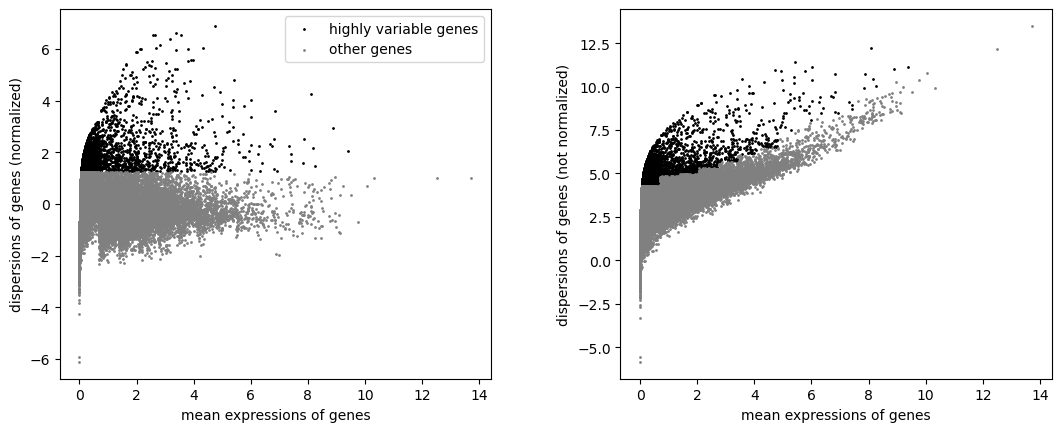

In [5]:
sc.pl.highly_variable_genes(mal, show=False)
plt.savefig(FIGDIR / "02_hvg_diagnostic.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 5 — Marker sanity check (MITF / SOX10 / NGFR / AXL)

These four genes define the Tsoi 2018 differentiation axis. A natural
expectation is "the key markers should be HVGs". **Read the result
carefully — the `seurat` method may *correctly* exclude some of them:**

- `flavor="seurat"` selects on **normalized dispersion**, not raw variance.
- **MITF / SOX10** are highly/consistently expressed lineage TFs. They *do*
  vary, but not *more than expected for their high mean expression*, so their
  normalized dispersion is near average → **not** selected. This is expected
  behavior, **not** a bug.
- **NGFR / AXL** are ON/OFF "switch" markers across states → very high
  normalized dispersion → selected.

This does **not** harm the analysis: PCA still captures the state axis via
the switch markers, and because we kept *all* genes, MITF/SOX10 stay
available for explicit Tsoi-state scoring later.

In [6]:
markers = ["MITF", "SOX10", "NGFR", "AXL"]
present = [m for m in markers if m in mal.var_names]
missing = [m for m in markers if m not in mal.var_names]
if missing:
    print("WARNING: not found in var_names:", missing)
print(mal.var.loc[present, ["highly_variable", "means", "dispersions_norm"]]
      .round(3))
print()
print("switch markers (AXL/NGFR) in HVG set:",
      bool(mal.var.loc[[m for m in ['AXL','NGFR'] if m in present],
                       'highly_variable'].all()))

       highly_variable  means  dispersions_norm
gene                                           
MITF             False  4.928             0.113
SOX10            False  3.139            -0.635
NGFR              True  3.160             6.377
AXL               True  2.300             2.748

switch markers (AXL/NGFR) in HVG set: True


## Step 6 — PCA  *(design decisions #3, #4, #5)*

`sc.pp.pca` with `mask_var="highly_variable"` computes components on the
2,000 HVGs only. `zero_center=True` (default) mean-centers each gene —
**this is the only centering applied; we do NOT `sc.pp.scale`.**
`svd_solver="arpack"` + fixed `random_state` make the result reproducible.

In [7]:
sc.pp.pca(mal, n_comps=50, mask_var="highly_variable",
          svd_solver="arpack", random_state=0)

vr = mal.uns["pca"]["variance_ratio"]
print("X_pca:", mal.obsm["X_pca"].shape)
print("PC1..PC5 variance explained (%):", np.round(vr[:5] * 100, 2))
print("PC10 (%):", round(float(vr[9] * 100), 2),
      "| cumulative top-10 (%):", round(float(vr[:10].sum() * 100), 1),
      "| cumulative top-30 (%):", round(float(vr[:30].sum() * 100), 1))

X_pca: (1257, 50)
PC1..PC5 variance explained (%): [8.13 6.7  3.89 2.36 2.13]
PC10 (%): 1.25 | cumulative top-10 (%): 30.9 | cumulative top-30 (%): 42.5


## Step 7 — Variance-explained (scree) plot

Expect a fast-decaying curve that flattens after ~PC10–20: the early PCs
hold the real signal, the tail is mostly noise.

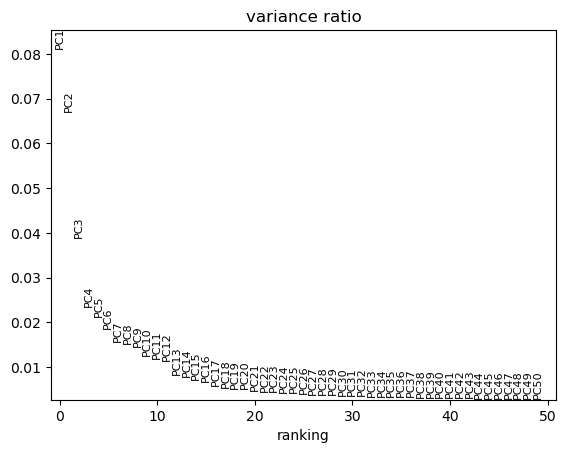

In [8]:
sc.pl.pca_variance_ratio(mal, n_pcs=50, log=False, show=False)
plt.savefig(FIGDIR / "02_pca_variance_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 8 — PCA colored by patient  *(THE key diagnostic)*

We color by the **categorical** `patient` column (a distinct color per
patient) rather than the numeric `tumor_id` — a categorical palette makes
batch structure far easier to read than a continuous colormap.

**How to read this:**
- *Cells separate into ~19 patient-colored blobs* → PC1/PC2 are driven by
  "which patient", i.e. **batch effect dominates** → batch correction needed.
- *Colors are intermixed with ~4 broad shapes* → PCs already reflect cell
  state; batch effect is mild.

Strong patient separation here is the explicit motivation for the Harmony
batch correction in the next quest (Q2.3).

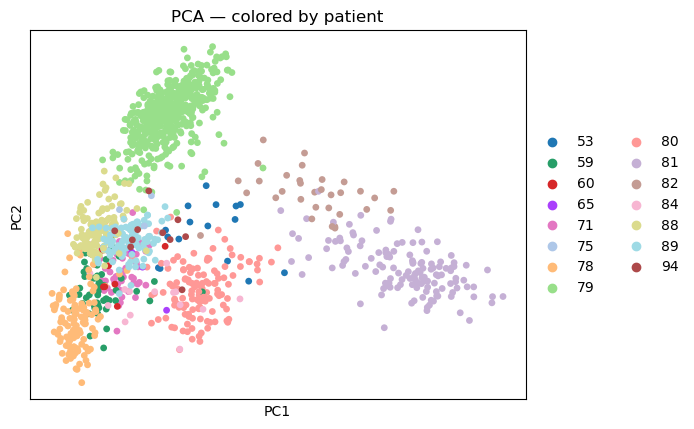

In [9]:
sc.pl.pca(mal, color="patient", title="PCA — colored by patient",
          show=False)
plt.savefig(FIGDIR / "02_pca_by_patient.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 9 — PCA colored by genes-detected (global view)

Coloring PC1 vs PC2 by `n_genes_by_counts` checks whether the leading axis
is driven by a *technical* gradient (library complexity) rather than
biology. A smooth color gradient along a PC is a warning sign.

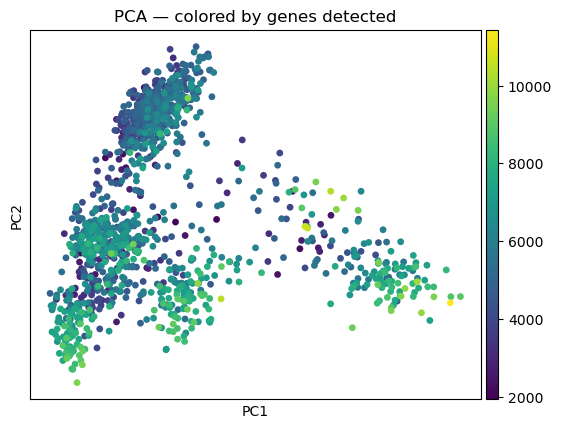

In [10]:
sc.pl.pca(mal, color="n_genes_by_counts",
          title="PCA — colored by genes detected", show=False)
plt.savefig(FIGDIR / "02_pca_by_ngenes.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 10 — Save

Persist the malignant AnnData with HVG marks + PCA, and reload to confirm it
round-trips.

In [11]:
mal.uns["q22"] = {
    "subset": "malignant_label == 'malignant'",
    "hvg_flavor": "seurat",
    "n_top_genes": 2000,
    "pca_n_comps": 50,
    "scaling": "NONE (no sc.pp.scale; pca zero_center only)",
    "built": str(date.today()),
}
mal.write_h5ad(OUT_H5AD)
print(f"Saved: {OUT_H5AD.resolve()}  ({OUT_H5AD.stat().st_size / 1e6:.1f} MB)")

chk = sc.read_h5ad(OUT_H5AD)
assert chk.shape == mal.shape
assert "X_pca" in chk.obsm and chk.obsm["X_pca"].shape[1] == 50
assert int(chk.var["highly_variable"].sum()) == 2000
print("Reload OK:", chk.shape, "| X_pca", chk.obsm["X_pca"].shape,
      "| HVG", int(chk.var["highly_variable"].sum()))

Saved: /Users/youyouwu/Desktop/melanoma-scrnaseq-reanalysis/data/processed/tirosh_malignant_pca.h5ad  (131.1 MB)
Reload OK: (1257, 23686) | X_pca (1257, 50) | HVG 2000


## Observed caveats — read before trusting the PCA

Three findings from this run a rigorous re-analysis must record:

**(A) Only 15 of 19 patients have malignant cells.** The 1,257 malignant
cells come from 15 patients (4 contributed only immune/stromal cells), and
several of those 15 are very small. Consequence: the batch covariate for
malignant-cell integration in Q2.3 / Stage 3 has 15 — not 19 — levels,
several of them tiny, which is hard for any batch-correction method to
handle reliably.

**(B) The top HVGs are immune/blood genes, not melanoma-state genes.** The
highest-dispersion HVGs include `HLA-DRA`, `HLA-DRB1`, `CCL4`, `CXCL13`,
`CD14`, `IGLL5`, `HBB`, `FDCSP`, `PLEK` — antigen-presentation, chemokine,
monocyte, immunoglobulin and erythroid markers. Tirosh's malignant calls are
CNV-inference based; residual immune signal (ambient RNA, doublets, or
imperfect calls) remains in some "malignant" cells, so PC1/PC2 may partly
encode immune contamination rather than only the melanocytic↔undifferentiated
axis. Tirosh 2016 and Balderson 2024 applied extra cleaning to malignant
cells; whether to add such a step here is an analysis-design decision for the
author — documented as a known limitation for now.

**(C) Strong patient separation in `PCA by patient`** (see figure): cells
occupy distinct patient territories. In melanoma this is *expected* —
malignant cells carry patient-specific copy-number and clonal genetics, so
"batch" here is largely **biological** patient identity, not merely a
technical artifact. This is precisely why naive PCA cannot expose cell
*states* shared across patients (motivating Harmony/scVI integration in
Q2.3), and simultaneously a warning that **over-correction could erase real
biology**.

## Conclusions — answers to the expected questions

1. **HVG count = 2,000** (exactly `n_top_genes`).
2. **Marker check:** AXL ✓ and NGFR ✓ are HVGs; **MITF and SOX10 are *not*** —
   correctly so, because `flavor="seurat"` selects on *normalized* dispersion
   and these high-mean lineage TFs are not unusually variable for their
   expression level. The differentiation axis is still captured (switch
   markers selected; all genes retained for later Tsoi scoring).
3. **Variance explained:** PC1 ≈ 8%, PC2 ≈ 7%, decaying to ≈1% by PC10 — a
   textbook scree shape; the first ~10–20 PCs hold the signal.
4. **PCA by patient:** the figure shows **strong patient-wise separation** —
   visual proof that patient identity (largely biological in malignant cells)
   dominates the leading PCs → **motivates Harmony batch correction in Q2.3.**
   See the *Observed caveats* section above for the 15/19-patient and
   immune-contamination findings.

Concrete numbers from this run are printed below.

In [12]:
hv = mal.var["highly_variable"]
vr = mal.uns["pca"]["variance_ratio"]
mk = mal.var.loc[present, "highly_variable"].to_dict()

print("=" * 60)
print("Q2.2 — ANSWERS (numbers from this run)")
print("=" * 60)
print(f"\n[1] malignant cells       : {mal.n_obs}")
print(f"[1] patients with malignant: {mal.obs['patient'].nunique()} of 19")
print(f"[1] HVGs selected         : {int(hv.sum())} / {mal.n_vars}")
print(f"\n[2] marker -> highly_variable:")
for g, v in mk.items():
    print(f"      {g:<6} {v}")
print(f"    (MITF/SOX10 False is EXPECTED under flavor='seurat')")
print(f"\n[3] variance: PC1 {vr[0]*100:.1f}% | PC2 {vr[1]*100:.1f}% | "
      f"PC10 {vr[9]*100:.2f}% | top-30 {vr[:30].sum()*100:.1f}%")
print(f"\n[4] -> inspect 02_pca_by_patient.png for batch structure;"
      f" feeds Q2.3 Harmony")

Q2.2 — ANSWERS (numbers from this run)

[1] malignant cells       : 1257
[1] patients with malignant: 15 of 19
[1] HVGs selected         : 2000 / 23686

[2] marker -> highly_variable:
      MITF   False
      SOX10  False
      NGFR   True
      AXL    True
    (MITF/SOX10 False is EXPECTED under flavor='seurat')

[3] variance: PC1 8.1% | PC2 6.7% | PC10 1.25% | top-30 42.5%

[4] -> inspect 02_pca_by_patient.png for batch structure; feeds Q2.3 Harmony
